# INFOSCI 301 · Week 3 — A traceable 3D extract

**Question:** what can a scan, a part annotation and a task description establish?

Data: [SceneFun3D on Hugging Face](https://huggingface.co/datasets/Voxel51/SceneFun3D), Voxel51 conversion of Delitzas et al., *SceneFun3D: Fine-Grained Functionality and Affordance Understanding in 3D Scenes*, CVPR 2024. [Original project](https://scenefun3d.github.io/). Data license: **CC BY-NC-SA 4.0**; this is publicly available data with conditions, not unrestricted reuse.

This notebook downloads one pinned 31.5 MB PCD and the annotation metadata. It needs Python, NumPy and Matplotlib; no GPU, Hugging Face token or AI API key. The supplied web demo already bundles a small extract. The CVPR paper is practice context and is not an eligible IEEE VIS assignment paper.

## 1. Download, verify and translate
Read the binary schema before decoding RGB. The packed color field uses float storage but its bits represent RGB. Keep one translation for both points and annotations.

In [1]:
from pathlib import Path
import urllib.request, json, hashlib
import numpy as np
import matplotlib.pyplot as plt
REVISION = '76803371aae67277cfa0cc29804db2368c6756ce'
SOURCE = f'https://huggingface.co/datasets/Voxel51/SceneFun3D/resolve/{REVISION}'
cache=Path('scenefun3d-cache'); cache.mkdir(exist_ok=True)
def obtain(name):
    path=cache/Path(name).name
    if not path.exists(): urllib.request.urlretrieve(SOURCE+'/'+name,path)
    return path
pcd=obtain('data/421061.pcd') # about 31.5 MB; no GPU required
metadata=obtain('samples.json')
blob=pcd.read_bytes()
assert hashlib.sha256(blob).hexdigest()=='f368d72b10c95d5b72f9c0d86b20c514cd4ecfb133d539e3ec1f178c3e7d1a38'
end=blob.index(b'DATA binary\n')+len(b'DATA binary\n')
header=blob[:end].decode()
assert 'FIELDS x y z rgb' in header and 'TYPE F F F F' in header
raw=np.frombuffer(blob[end:],dtype=[('x','<f4'),('y','<f4'),('z','<f4'),('rgb','<u4')])
xyz=np.column_stack([raw[a] for a in ['x','y','z']])
assert len(raw)==1966804 and np.isfinite(xyz).all()
origin=(xyz.min(0)+xyz.max(0))/2
indices=np.linspace(0,len(raw)-1,18000,dtype=int)
points=(xyz[indices]-origin).round(4)
rgbbits=raw['rgb'][indices]
colors=np.column_stack([(rgbbits>>16)&255,(rgbbits>>8)&255,rgbbits&255])
sample=next(x for x in json.loads(metadata.read_text())['samples'] if x.get('visit_id')=='421061' and x.get('functional_elements'))
parts=sample['functional_elements']['detections']
print('Source points:',len(raw),'| sampled points:',len(points),'| parts:',len(parts))
print('Source revision:',REVISION)


Source points: 1966804 | sampled points: 18000 | parts: 12
Source revision: 76803371aae67277cfa0cc29804db2368c6756ce


## 2. Inspect the geometry
Rotate this view in the web demo. Identify an area where downsampling hides a small part. Do not infer missing geometry or label a motion annotation as a successful action.

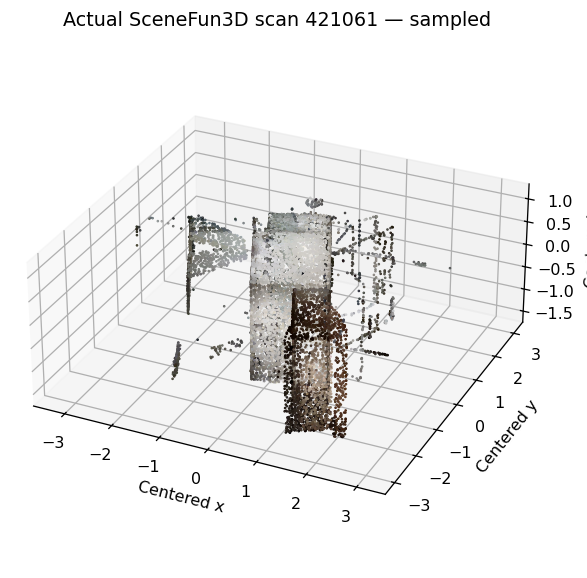

In [2]:
fig=plt.figure(figsize=(9,6)); ax=fig.add_subplot(111,projection='3d')
ax.scatter(points[:,0],points[:,1],points[:,2],c=colors/255,s=.4,depthshade=False)
ax.set_box_aspect(np.ptp(points,axis=0));ax.view_init(elev=29,azim=-65)
ax.set(xlabel='Centered x',ylabel='Centered y',zlabel='Centered z',title='Actual SceneFun3D scan 421061 — sampled')


## 3. Define the relationship types before laying out the graph

**Important source distinction:** this extract retains seven affordance annotations and five `exclude` annotations. The source uses `exclude` for poorly captured geometry and omits it from evaluation. It is not an affordance class. Preserve it as an explicit data-quality signal. [Annotation documentation](https://scenefun3d.github.io/documentation/dataset/annotations/).

In [3]:
# Preserve source annotation IDs; apply the SAME translation to every spatial field.
rows=[]
for i,p in enumerate(parts):
    rows.append({'part':f'P{i+1:02d}','affordance':p['label'],'center':(np.array(p['location'])-origin).round(5).tolist(),'motion':p.get('motion_type'),'tasks':p.get('descriptions',[])})
print('First annotation:',rows[0])
print('Affordance categories:',sorted({x['affordance'] for x in rows}))
assert all(len(x['center'])==3 for x in rows)
print('Graph semantics: scene CONTAINS part; part HAS_ANNOTATED_AFFORDANCE label; part HAS_TASK_DESCRIPTION text.')


First annotation: {'part': 'P01', 'affordance': 'foot_push', 'center': [-0.0633, -0.73846, -1.31958], 'motion': 'trans', 'tasks': ['Open the trash can']}
Affordance categories: ['exclude', 'foot_push', 'hook_turn', 'plug_in', 'rotate', 'tip_push']
Graph semantics: scene CONTAINS part; part HAS_ANNOTATED_AFFORDANCE label; part HAS_TASK_DESCRIPTION text.


## 4. Export reproducible provenance

In [4]:
manifest={'dataset':'Voxel51/SceneFun3D','scene':'421061','revision':REVISION,'license':'CC-BY-NC-SA-4.0','source_count':len(raw),'sample_count':len(points),'origin':origin.tolist(),'method':'Evenly spaced original row indices; shared translation; no axis rotation','source_sha256':hashlib.sha256(blob).hexdigest()}
Path('scene_manifest_student.json').write_text(json.dumps(manifest,indent=2))
print('Wrote scene_manifest_student.json')


Wrote scene_manifest_student.json


## 5. Additional data + emerging technology exercise
Create 12 rows, one per part, with `part_id`, `viewpoint`, `visibility_rating`, `ambiguity_note`, `annotator_code`, and `protocol_version`. Each partner codes independently; reconcile disagreements and keep both initial judgments. These are **student judgments**, not source labels. Join on the source annotation ID; do not use guessed names.

Use GPT-6 (if available in the course-approved workspace) to propose two UI alternatives using a tiny public sample. Check its field mappings, citations and code with your partner. Record prompt, model/date, accepted/rejected suggestions and human checks. Do not send classmate identities or unpublished reports. This is development assistance, not an embodied policy or 3D capability evaluation.

Validate domain relevance with a task walkthrough; data/task mapping with a join audit; idiom with a 2D-versus-3D task comparison; algorithm with finite-coordinate, count and runtime checks. Explain why one scene cannot support claims about general robot performance.